In [2]:
from innolux import *
project_data_path = data_path / "T2 6117" / "ra"

In [15]:
raw_df = pl.read_excel(project_data_path / "治具電壓量測記錄_20260402.xlsx")
raw_df

片號,治具,Adapter,時間(min),VDDIO,AVDD,AVEE,VGHO,VGLO
str,str,i64,i64,f64,f64,f64,f64,f64
"""201A71""","""E59TL8-001""",12,0,1.85,5.99,-6.15,14.09,-14.24
"""201A41""","""AVDD#2""",7,0,1.85,6.01,-6.14,14.18,-14.17
"""201A71""","""E59TL8-001""",12,5,1.87,5.99,-6.15,14.08,-14.25
"""201A41""","""AVDD#2""",7,5,1.85,6.01,-6.14,14.18,-14.17
"""201A71""","""E59TL8-001""",12,10,1.87,6.0,-6.15,14.09,-14.25
…,…,…,…,…,…,…,…,…
"""201A61""","""iMT""",4,40,1.8,6.05,-5.99,14.15,-14.25
"""201A61""","""iMT""",4,45,1.8,6.05,-5.99,14.15,-14.25
"""201A61""","""iMT""",4,50,1.8,6.05,-5.99,14.15,-14.25


In [5]:
raw_df.columns

['片號', '治具', 'Adapter', '時間(min)', 'VDDIO', 'AVDD', 'AVEE', 'VGHO', 'VGLO']

In [16]:
plt_df = raw_df.unpivot(
    index=['片號', '治具', 'Adapter', '時間(min)'],
    on=['VDDIO', 'AVDD', 'AVEE', 'VGHO', 'VGLO'],
    variable_name="Type",
    value_name="Voltage(V)"
)

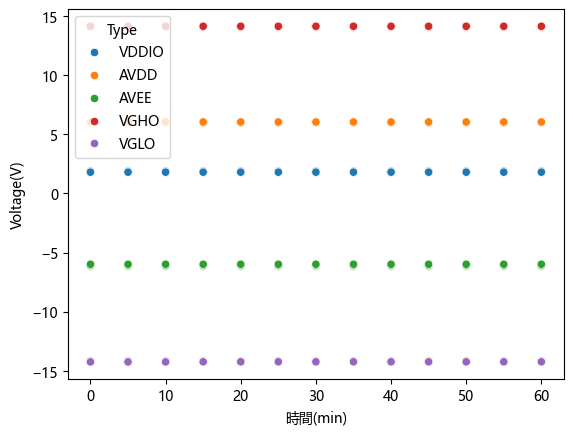

In [17]:
ax = sns.scatterplot(
    plt_df,
    x='時間(min)',
    y='Voltage(V)',
    hue="Type",
)
sns.move_legend(ax, "upper left")

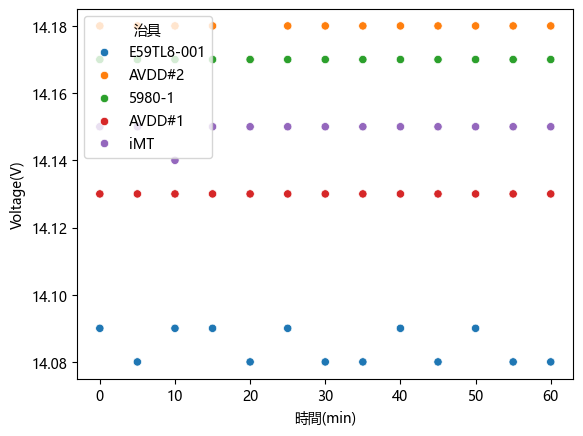

In [19]:
ax2 = sns.scatterplot(
    plt_df.filter(pl.col("Type")=="VGHO"),
    x='時間(min)',
    y='Voltage(V)',
    hue="治具",
)
sns.move_legend(ax2, "upper left")

In [14]:
raw_df.filter(pl.col("治具")=="AVDD#2")

片號,治具,Adapter,時間(min),VDDIO,AVDD,AVEE,VGHO,VGLO
str,str,i64,i64,f64,f64,f64,f64,f64
"""201A41""","""AVDD#2""",7,0,1.85,6.01,-6.14,14.18,-14.17
"""201A41""","""AVDD#2""",7,5,1.85,6.01,-6.14,14.18,-14.17
"""201A41""","""AVDD#2""",7,10,1.86,6.01,-6.14,14.18,-14.17
"""201A41""","""AVDD#2""",7,15,1.86,6.01,-6.14,14.18,-14.17
"""201A41""","""AVDD#2""",7,20,1.86,6.01,-6.14,14.17,-14.17
…,…,…,…,…,…,…,…,…
"""201A41""","""AVDD#2""",7,30,1.86,6.01,-6.14,14.18,-14.17
"""201A41""","""AVDD#2""",7,45,1.86,6.01,-6.14,14.18,-14.17
"""201A41""","""AVDD#2""",7,50,1.86,6.01,-6.14,14.18,-14.17
